<h1>Install and Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

Matplotlib is building the font cache; this may take a moment.


<h1>Import CSV Data File and Convert to Pandas Dataset

In [5]:
df = pd.read_csv('credit_risk_dataset.csv')

<h1>Head and Tail

In [6]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [7]:
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


<h1>Statistics and Logistics

In [9]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Loan Grade, Person Home Ownership, Loan Intent, Loan Status, cb_person_default_on_file: Counts

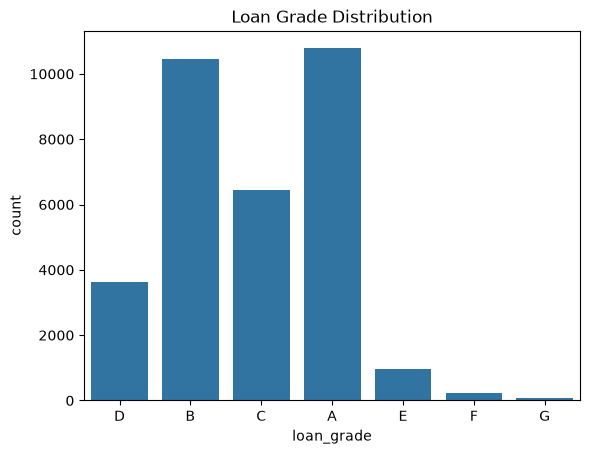

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64


In [11]:
#loan grade distribution
sns.countplot(x='loan_grade', data=df)
plt.title('Loan Grade Distribution')
plt.show()
count_by_grade = df['loan_grade'].value_counts()
print(count_by_grade)

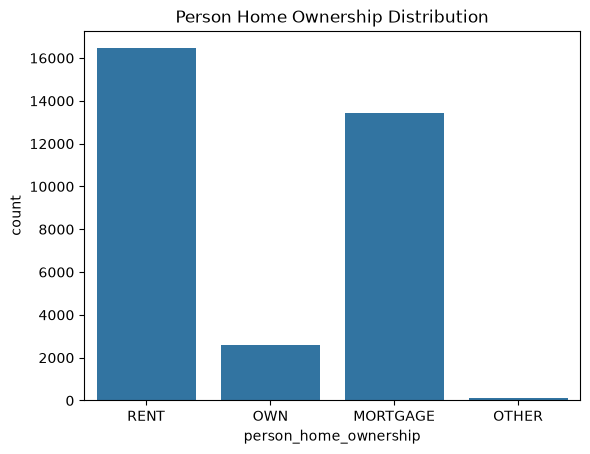

person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64


In [12]:
#person home ownership distribution
sns.countplot(x='person_home_ownership', data=df)
plt.title('Person Home Ownership Distribution')
plt.show()
count_by_home_ownership = df['person_home_ownership'].value_counts()
print(count_by_home_ownership)

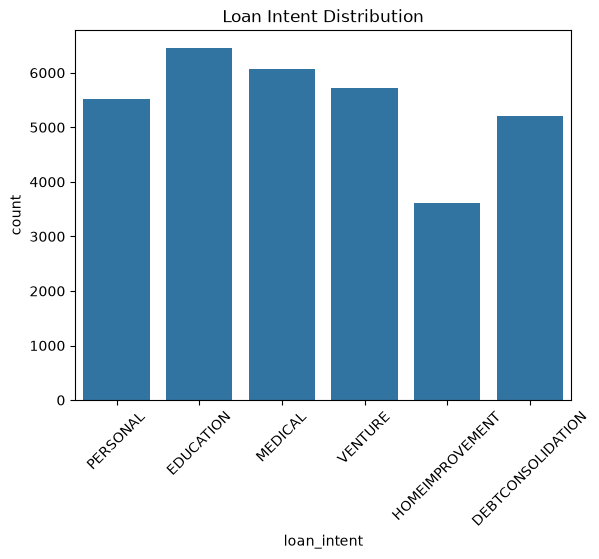

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64


In [13]:
#loan intent distribution
sns.countplot(x='loan_intent', data=df)
plt.title('Loan Intent Distribution')
plt.xticks(rotation=45)
plt.show()
count_by_loan_intent = df['loan_intent'].value_counts()
print(count_by_loan_intent)

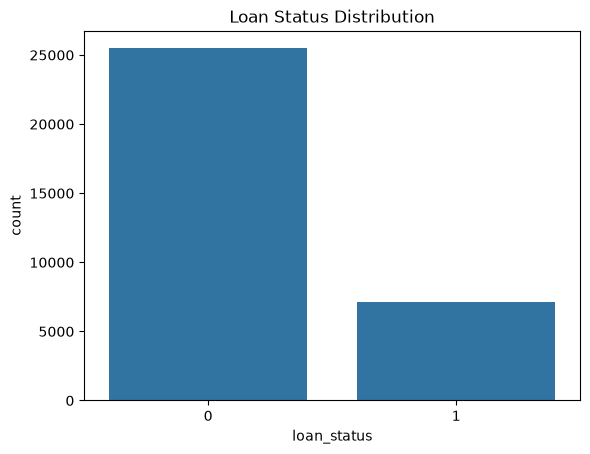

loan_status
0    25473
1     7108
Name: count, dtype: int64


In [14]:
#loan status distribution
sns.countplot(x='loan_status', data=df)
plt.title('Loan Status Distribution')
plt.show()
count_by_loan_status = df['loan_status'].value_counts()
print(count_by_loan_status)

In [18]:
#percentage of loans appproved vs rejected
loan_status_counts = df['loan_status'].value_counts()
print(loan_status_counts)

loan_status
0    25473
1     7108
Name: count, dtype: int64


In [21]:
#percentage of repaid vs defaulted loans
# loan_status is encoded as integers: 0 = approved (loan repaid), 1 = rejected (defaulted)
total_loans = len(df)
approved_loans = loan_status_counts.get(0, 0)
rejected_loans = loan_status_counts.get(1, 0)
approved_percentage = (approved_loans / total_loans) * 100
rejected_percentage = (rejected_loans / total_loans) * 100
print(f"Approved Loans: {approved_percentage:.2f}%")
print(f"Rejected Loans: {rejected_percentage:.2f}%")

Approved Loans: 78.18%
Rejected Loans: 21.82%


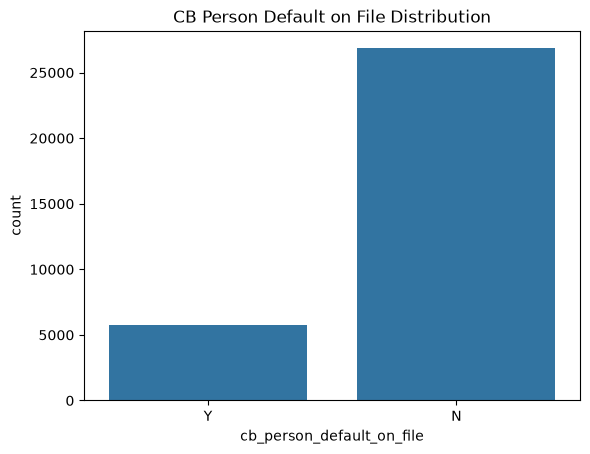

cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


In [22]:
#cb person default on file
sns.countplot(x='cb_person_default_on_file', data=df)
plt.title('CB Person Default on File Distribution')
plt.show()
count_by_default_on_file = df['cb_person_default_on_file'].value_counts()
print(count_by_default_on_file)

In [27]:
#percentage of cb person default on file
default_on_file_counts = df['cb_person_default_on_file'].value_counts()
total_records = len(df)
default_on_file_percentage = (default_on_file_counts / total_records) * 100
print(default_on_file_percentage.map("{:.2f}%".format))

cb_person_default_on_file
N    82.37%
Y    17.63%
Name: count, dtype: str
